# Симулятор газового куста

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math, warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True,
                     'grid.alpha': 0.35, 'axes.spines.top': False,
                     'axes.spines.right': False})

from src.fluid      import Fluid
from src.reservoir  import ResProps, Reservoir
from src.pipe       import Pipe
from src.well       import Well
from src.compressor import DCS
from src.simulator  import FieldSimulator

## Исходные данные

In [26]:
M     = 0.01604 
rho_c = 0.6799
xa    = 0.4561     
xy    = 0.7852     
T_res = 310.0
P_res = 100.0

fluid = Fluid(M=M, rho_c=rho_c, xa=xa, xy=xy, T=T_res)

V_res     = math.pi * 500**2 * 25
resprops  = ResProps(P=P_res, V=V_res, T=T_res)
reservoir = Reservoir(resprops=resprops, fluid=fluid)

well_params = [
    dict(k=50, h=25, re=500, rw=0.1, L=2000, H=1800, D=0.062, roughness=4.6e-5, name='Скв-1'),
    dict(k=50, h=25, re=500, rw=0.1, L=2500, H=1900, D=0.062, roughness=4.6e-5, name='Скв-2'),
    dict(k=50, h=25, re=500, rw=0.1, L=1800, H=1600, D=0.073, roughness=4.6e-5, name='Скв-3'),
]

wells = []
for wp in well_params:
    pipe = Pipe(L=wp['L'], D=wp['D'], roughness=wp['roughness'],
                fluid=fluid, vertical_depth=wp['H'], name=wp['name'])
    wells.append(Well(fluid=fluid, k=wp['k'], h=wp['h'],
                      re=wp['re'], rw=wp['rw'], pipe=pipe, name=wp['name']))

shlyf = Pipe(L=5000, D=0.200, roughness=4.6e-5, fluid=fluid,
             vertical_depth=0.0, name='Шлейф')
dcs   = DCS(CR=1.5, P_line=5.0, q_ext=500.0)
sim   = FieldSimulator(reservoir=reservoir, wells=wells, shlyf=shlyf, dcs=dcs)

print(f'V_res = {V_res/1e6:.3f} млн м³  |  P_in ДКС = {dcs.P_in():.2f} атм')
print(f'rho_c = {rho_c:.4f}  |  Z(100) = {fluid.z(100):.4f}  |  ρ(100) = {fluid.ro(100):.2f} кг/м³')


V_res = 19.635 млн м³  |  P_in ДКС = 3.33 атм
rho_c = 0.6799  |  Z(100) = 0.8735  |  ρ(100) = 72.19 кг/м³


## 1. PVT-модель

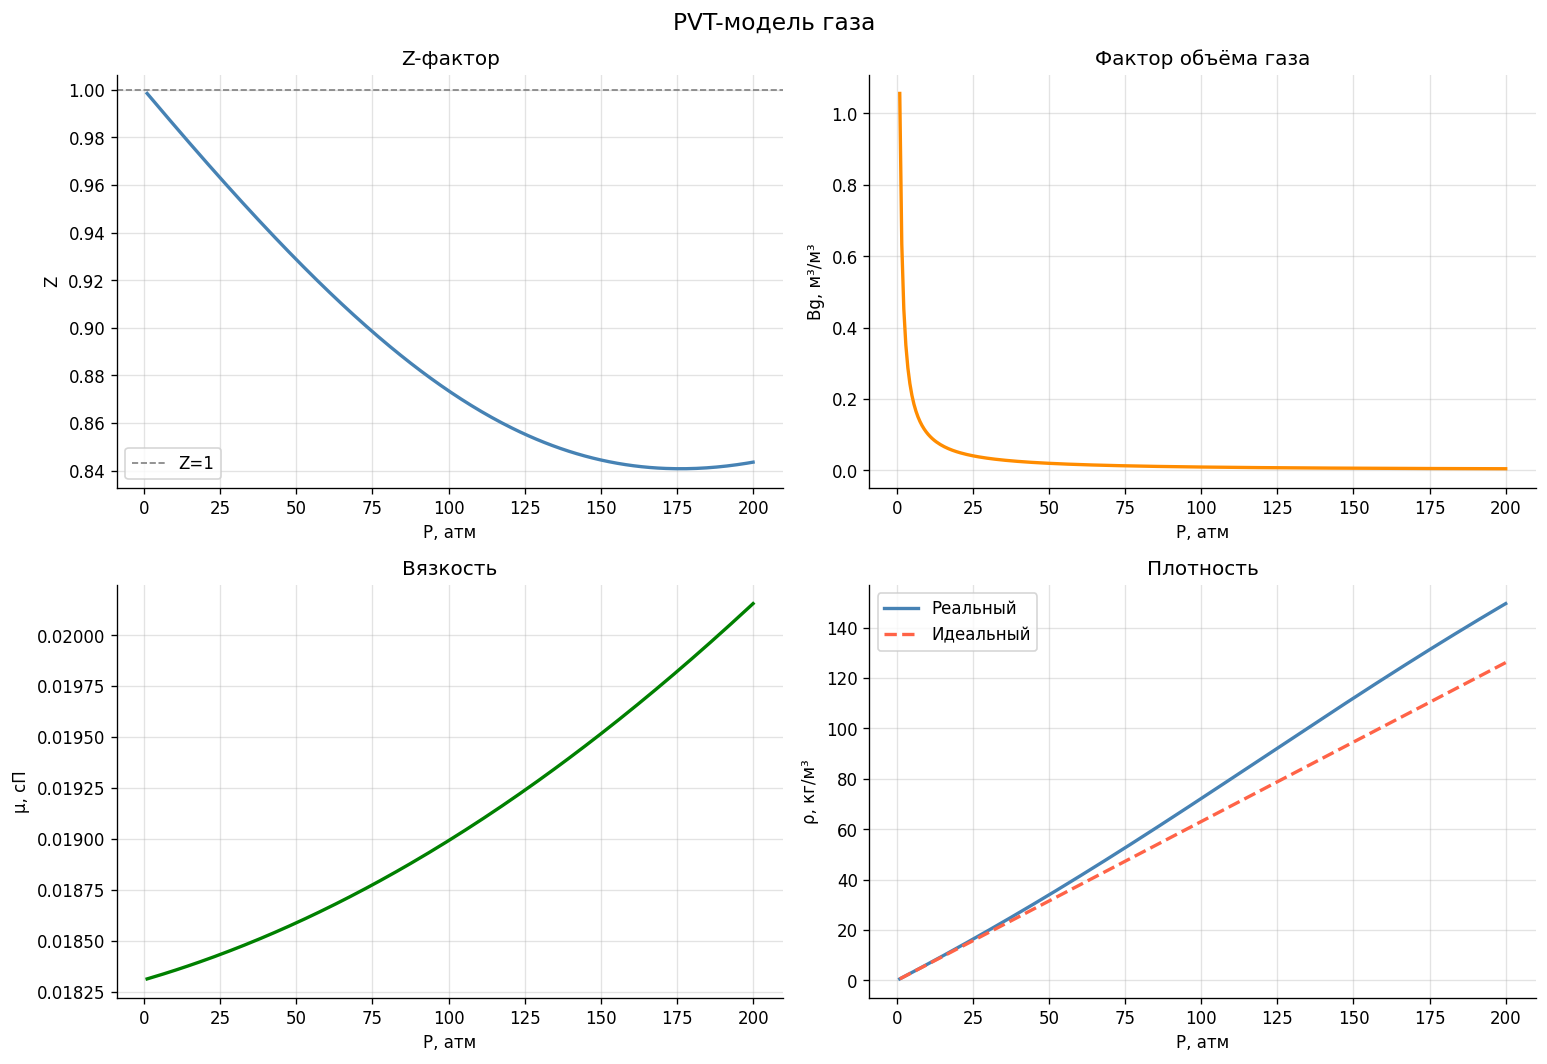

Z(100)  = 0.8735
ρ(100)  = 72.19 кг/м³
Bg(100) = 0.00924 м³/м³
ρ_std   = 0.6668 кг/м³


In [27]:
P_range  = np.linspace(1, 200, 300)
Z_vals   = [fluid.z(p)  for p in P_range]
Bg_vals  = [fluid.bg(p) for p in P_range]
mu_vals  = [fluid.mu(p) for p in P_range]
ro_real  = [fluid.ro(p) for p in P_range]
ro_ideal = [p * 101325 * M / (8.314 * T_res) for p in P_range]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('PVT-модель газа', fontsize=14)

axes[0,0].plot(P_range, Z_vals, 'steelblue', lw=2)
axes[0,0].axhline(1.0, color='gray', ls='--', lw=1, label='Z=1')
axes[0,0].set(xlabel='P, атм', ylabel='Z', title='Z-фактор')
axes[0,0].legend()

axes[0,1].plot(P_range, Bg_vals, 'darkorange', lw=2)
axes[0,1].set(xlabel='P, атм', ylabel='Bg, м³/м³', title='Фактор объёма газа')

axes[1,0].plot(P_range, mu_vals, 'green', lw=2)
axes[1,0].set(xlabel='P, атм', ylabel='μ, сП', title='Вязкость')

axes[1,1].plot(P_range, ro_real,  'steelblue', lw=2, label='Реальный')
axes[1,1].plot(P_range, ro_ideal, 'tomato', lw=2, ls='--', label='Идеальный')
axes[1,1].set(xlabel='P, атм', ylabel='ρ, кг/м³', title='Плотность')
axes[1,1].legend()

plt.tight_layout()
plt.show()

print(f'Z(100)  = {fluid.z(100):.4f}')
print(f'ρ(100)  = {fluid.ro(100):.2f} кг/м³')
print(f'Bg(100) = {fluid.bg(100):.5f} м³/м³')
print(f'ρ_std   = {fluid.ro_std():.4f} кг/м³')

## 2. Кривые IPR

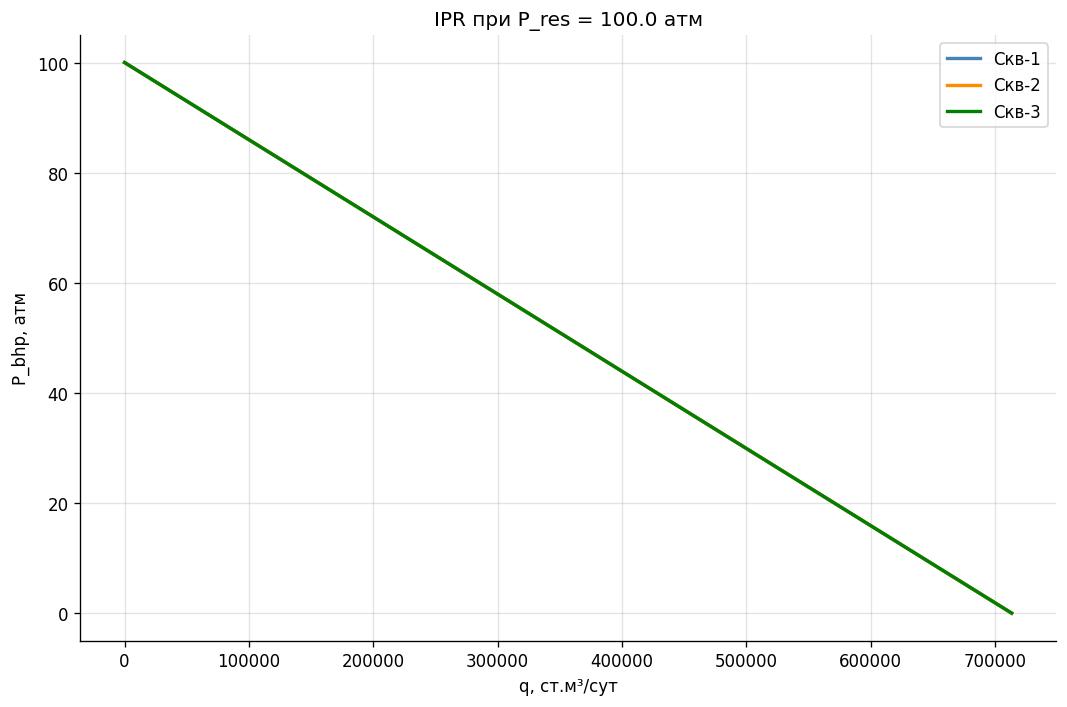

In [28]:
P_res = 100.0
colors     = ['steelblue', 'darkorange', 'green']

fig, ax = plt.subplots(figsize=(9, 6))
for well, color in zip(wells, colors):
    pts = well.ipr(P_res, n_points=100)
    ax.plot([p[0] for p in pts], [p[1] for p in pts], color=color, lw=2, label=well.name)
ax.set(xlabel='q, ст.м³/сут', ylabel='P_bhp, атм',
       title=f'IPR при P_res = {P_res} атм')
ax.legend()
plt.tight_layout()
plt.show()                      

## 3. Гидравлика — VLP и λ(Re)

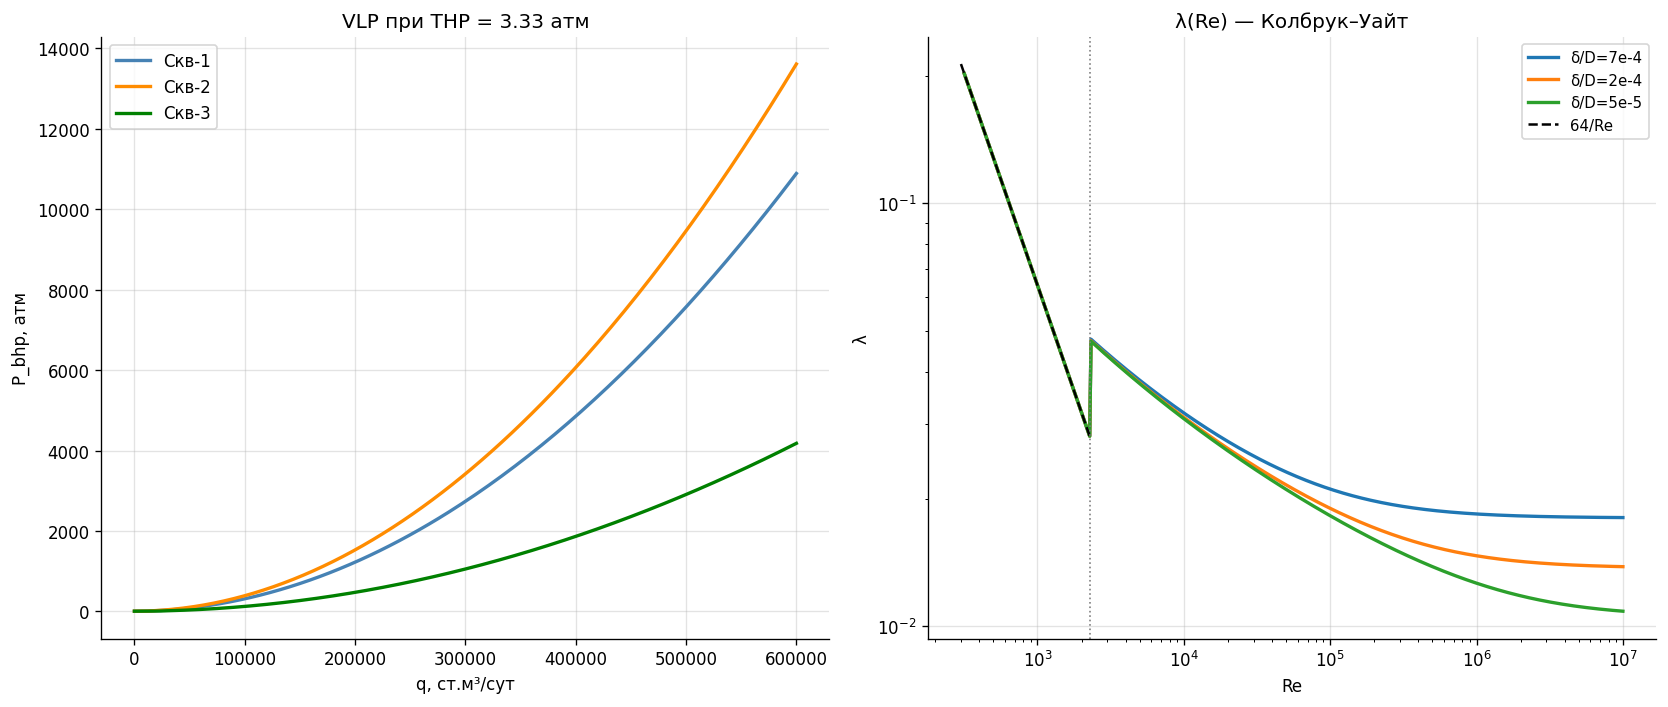

In [29]:
THP = 3.33        # давление на устье, атм

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for well, color in zip(wells, colors):
    pts = well.vlp(THP, q_max=600000, n_points=200)
    axes[0].plot([p[0] for p in pts], [p[1] for p in pts],
                 color=color, lw=2, label=well.name)
axes[0].set(xlabel='q, ст.м³/сут', ylabel='P_bhp, атм',
            title=f'VLP при THP = {THP} атм')
axes[0].legend()

Re_range   = np.logspace(2.5, 7, 500)
eps_vals   = [7e-4, 2e-4, 5e-5]
eps_labels = ['δ/D=7e-4', 'δ/D=2e-4', 'δ/D=5e-5']
for eps, lbl, color in zip(eps_vals, eps_labels, colors):
    lam_vals = [wells[0].pipe._friction_factor(Re, eps) for Re in Re_range]
    axes[1].loglog(Re_range, lam_vals, lw=2, label=lbl)
axes[1].loglog(np.linspace(300, 2300, 50), 64/np.linspace(300,2300,50),
               'k--', lw=1.5, label='64/Re')
axes[1].axvline(2300, color='gray', ls=':', lw=1)
axes[1].set(xlabel='Re', ylabel='λ', title='λ(Re) — Колбрук–Уайт')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 4. Рабочая точка — IPR ∩ VLP

Реальное P_man = 53.197 атм (от ДКС: 3.333 атм)
  Скв-1: Q=164913 ст.м³/сут, BHP=76.88 атм
  Скв-2: Q=152058 ст.м³/сут, BHP=78.69 атм
  Скв-3: Q=217900 ст.м³/сут, BHP=69.46 атм


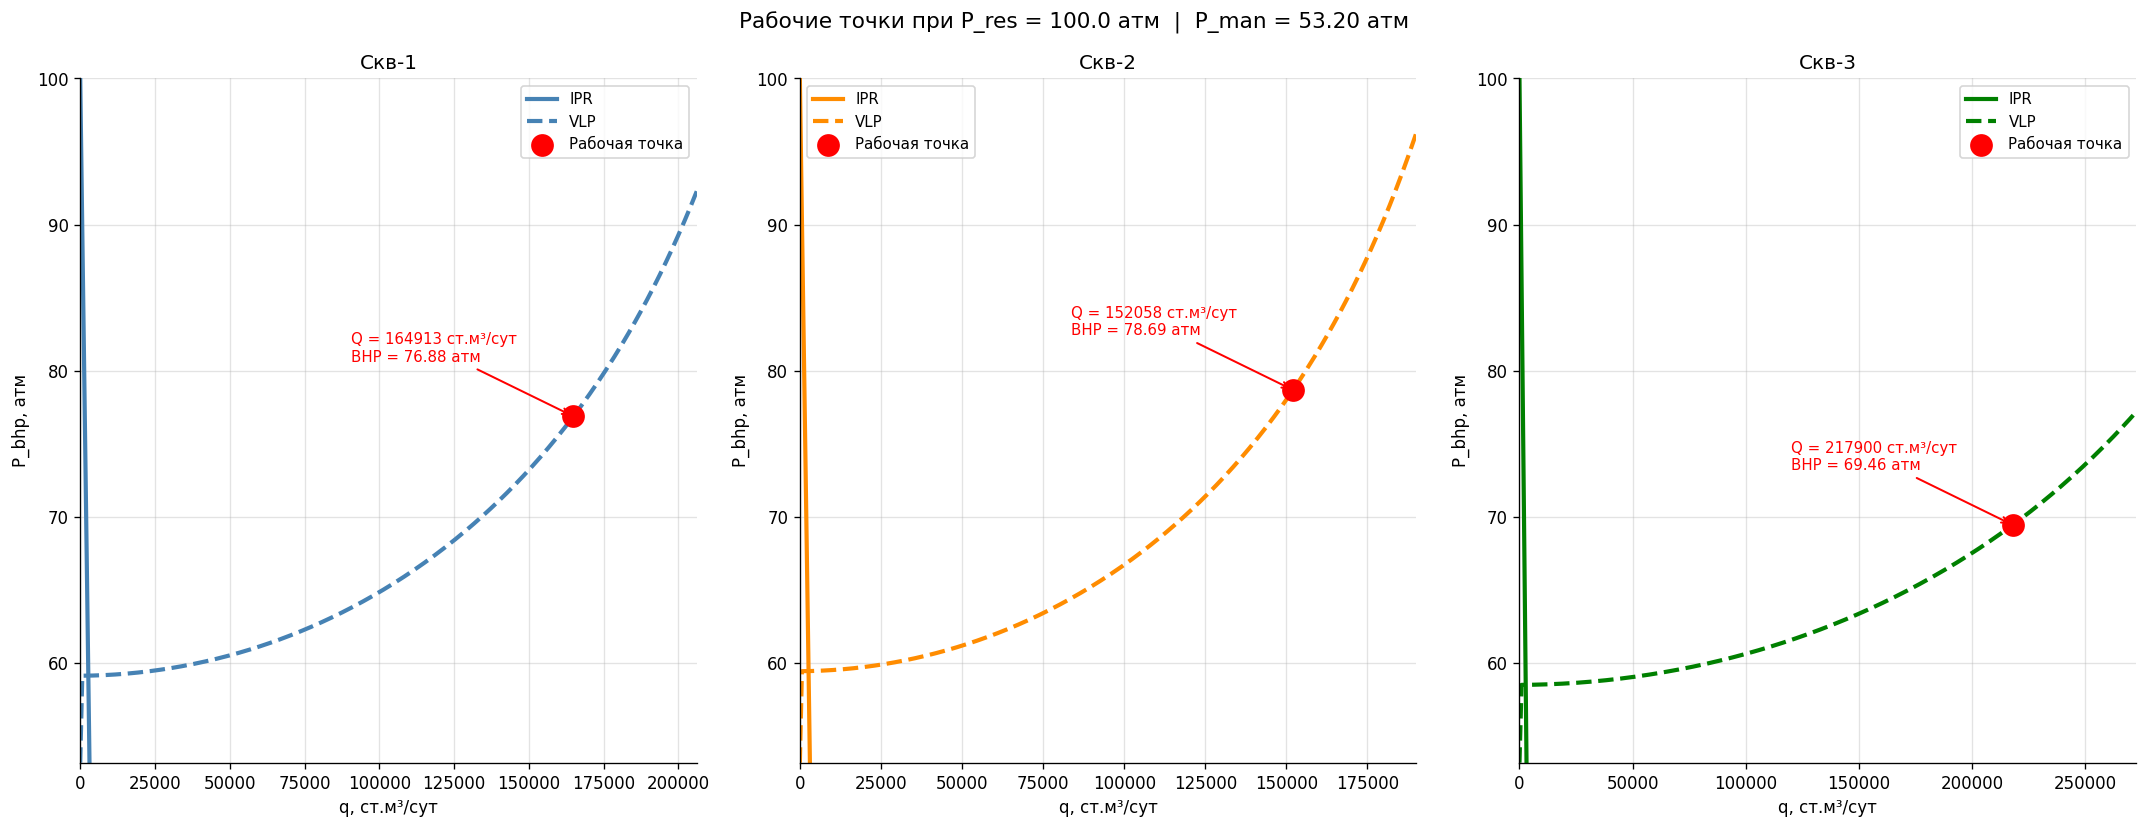

In [ ]:
reservoir.resprops.P = P_res
colors = ['steelblue', 'darkorange', 'green']

# Получаем реальное давление на манифолде из симулятора
states_wp  = sim.solve(P_res)
P_man_real = states_wp['well_1'].P_out
print(f'Реальное P_man = {P_man_real:.3f} атм (от ДКС: {dcs.P_in():.3f} атм)')

fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=False)
fig.suptitle(f'Рабочие точки при P_res = {P_res} атм  |  P_man = {P_man_real:.2f} атм',
             fontsize=13)

for idx, (well, color) in enumerate(zip(wells, colors)):
    ax  = axes[idx]
    key = f'well_{idx+1}'

    q_op   = states_wp[key].q_std
    bhp_op = states_wp[key].P_in   # давление на забое в рабочей точке

    # --- диапазон по q ---
    q_max_plot = q_op * 1.25
    q_range    = np.linspace(0, q_max_plot, 300)

    # --- IPR (кривая притока): P_bhp = P_res - q/C  ---
    # C вычисляем через well.q: q = C*(P_res - P_bhp)  =>  C = well.q(P_res, 0) / P_res
    mu_avg  = well.fluid.mu((P_res + bhp_op) / 2)
    C_well  = (well._beta * well.k * well.h) / (mu_avg * well._ln)
    bhp_ipr = [max(P_res - q / C_well, 0.0) for q in q_range]  # ИСПРАВЛЕНО: нет Bg

    # --- VLP (кривая подъёма): P_bhp = P_man + dP_труба(q) ---
    bhp_vlp = [P_man_real + well.pipe.dp(P_man_real, q).dP for q in q_range]

    # --- масштаб по P ---
    p_min = max(0, min(bhp_vlp[0], bhp_op * 0.8))
    p_max = min(P_res,  max(bhp_ipr[0], bhp_op * 1.15))

    ax.plot(q_range, bhp_ipr, color=color,      lw=2.5, label='IPR')
    ax.plot(q_range, bhp_vlp, color=color,      lw=2.5, ls='--', label='VLP')
    ax.scatter([q_op], [bhp_op], color='red', s=160, zorder=6,
               label=f'Рабочая точка')
    ax.annotate(
        f'Q = {q_op:.0f} ст.м³/сут\nBHP = {bhp_op:.2f} атм',
        xy=(q_op, bhp_op),
        xytext=(q_op * 0.55, bhp_op + (p_max - p_min) * 0.08),
        fontsize=9, color='red',
        arrowprops=dict(arrowstyle='->', color='red', lw=1.2)
    )
    ax.set_xlim(0, q_max_plot)
    ax.set_ylim(p_min, p_max)
    ax.set(xlabel='q, ст.м³/сут', ylabel='P_bhp, атм', title=well.name)
    ax.legend(fontsize=9)
    print(f'  {well.name}: Q={q_op:.0f} ст.м³/сут, BHP={bhp_op:.2f} атм')

plt.tight_layout()
plt.show()


## 5. Динамика — 180 суток

In [31]:
reservoir.resprops.P = P_res
df = sim.run(N_days=180 , dt=1.0)

Запуск симуляции на 180 суток...
День    0 | P_res = 100.00 атм
День   30 | P_res = 99.25 атм
День   60 | P_res = 98.50 атм
День   90 | P_res = 97.76 атм
День  120 | P_res = 97.02 атм
День  150 | P_res = 96.28 атм
День  180 | P_res = 95.56 атм
Симуляция завершена.



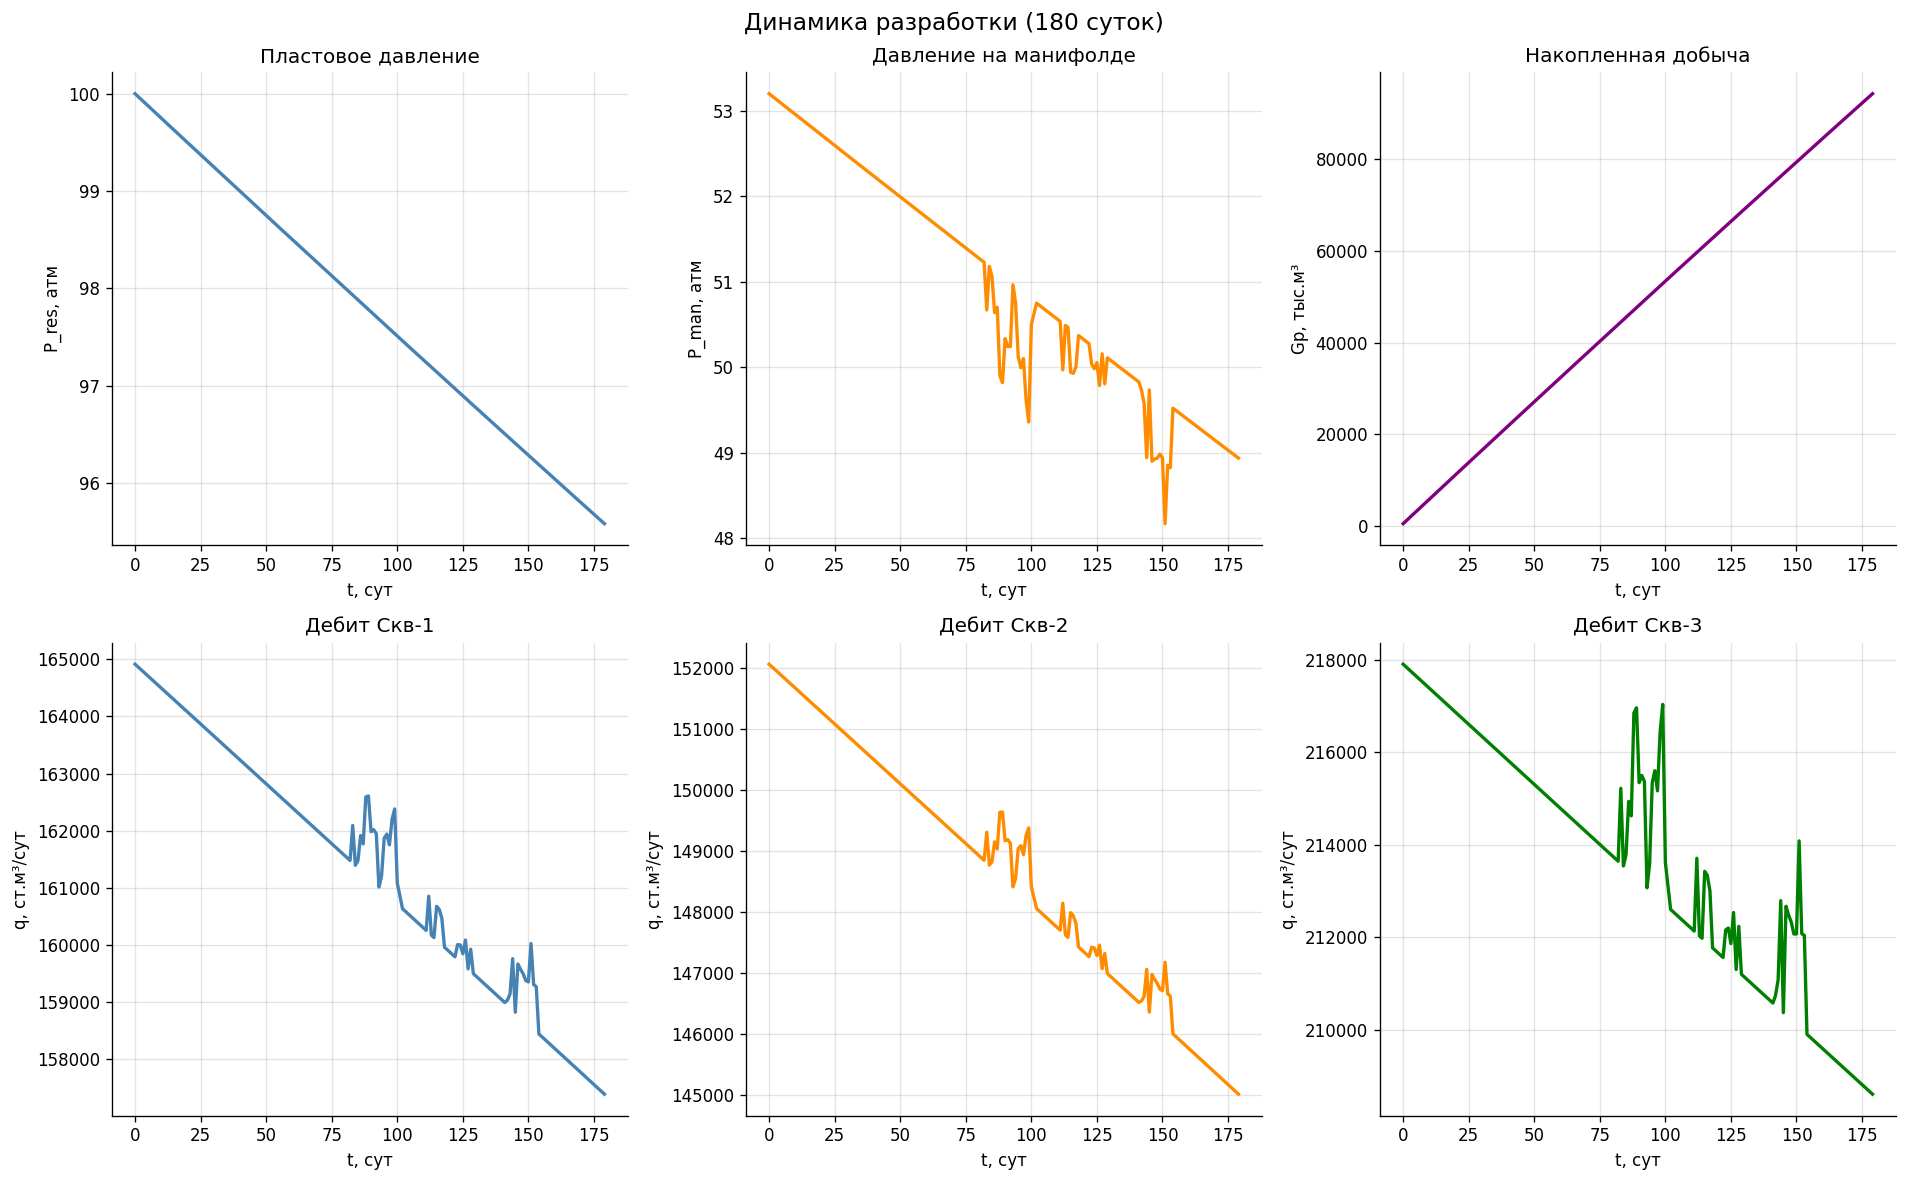

P_res конец: 95.58 атм
Gp итого:    94245.3 тыс.м³


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Динамика разработки (180 суток)', fontsize=14)
t = df['t']

axes[0,0].plot(t, df['P_res'], 'steelblue', lw=2)
axes[0,0].set(xlabel='t, сут', ylabel='P_res, атм', title='Пластовое давление')

axes[0,1].plot(t, df['P_man'], 'darkorange', lw=2)
axes[0,1].set(xlabel='t, сут', ylabel='P_man, атм', title='Давление на манифольде')

axes[0,2].plot(t, df['Gp'], 'purple', lw=2)
axes[0,2].set(xlabel='t, сут', ylabel='Gp, тыс.м³', title='Накопленная добыча')

for i, (col, color) in enumerate(zip(['q1','q2','q3'], colors)):
    axes[1,i].plot(t, df[col], color=color, lw=2)
    axes[1,i].set(xlabel='t, сут', ylabel='q, ст.м³/сут',
                  title=f'Дебит {wells[i].name}')

plt.tight_layout()
plt.show()
print(f'P_res конец: {df["P_res"].iloc[-1]:.2f} атм')
print(f'Gp итого:    {df["Gp"].iloc[-1]:.1f} тыс.м³')

## 6. Анализ влияния CR

In [33]:
CR_values  = [1.0, 1.5, 2.0, 3.0]
cr_colors  = ['gray', 'steelblue', 'darkorange', 'red']
results_cr = {}

for CR in CR_values:
    reservoir.resprops.P = P_res                                
    dcs.set_compression_ratio(CR)
    sim_cr        = FieldSimulator(reservoir=reservoir, wells=wells, shlyf=shlyf, dcs=dcs)
    df_cr         = sim_cr.run(N_days=180, dt=1.0)
    results_cr[CR] = df_cr
    print(f'CR={CR}: Gp={df_cr["Gp"].iloc[-1]:.1f} тыс.м³, '
          f'P_res={df_cr["P_res"].iloc[-1]:.2f} атм')

dcs.set_compression_ratio(1.5)

Запуск симуляции на 180 суток...
День    0 | P_res = 100.00 атм
День   30 | P_res = 99.25 атм
День   60 | P_res = 98.51 атм
День   90 | P_res = 97.77 атм
День  120 | P_res = 97.04 атм
День  150 | P_res = 96.31 атм
День  180 | P_res = 95.59 атм
Симуляция завершена.

CR=1.0: Gp=93485.8 тыс.м³, P_res=95.62 атм
Запуск симуляции на 180 суток...
День    0 | P_res = 100.00 атм
День   30 | P_res = 99.25 атм
День   60 | P_res = 98.50 атм
День   90 | P_res = 97.76 атм
День  120 | P_res = 97.02 атм
День  150 | P_res = 96.28 атм
День  180 | P_res = 95.56 атм
Симуляция завершена.

CR=1.5: Gp=94245.3 тыс.м³, P_res=95.58 атм
Запуск симуляции на 180 суток...
День    0 | P_res = 100.00 атм
День   30 | P_res = 99.24 атм
День   60 | P_res = 98.49 атм
День   90 | P_res = 97.75 атм
День  120 | P_res = 97.01 атм
День  150 | P_res = 96.27 атм
День  180 | P_res = 95.54 атм
Симуляция завершена.

CR=2.0: Gp=94593.5 тыс.м³, P_res=95.56 атм
Запуск симуляции на 180 суток...
День    0 | P_res = 100.00 атм
День   30

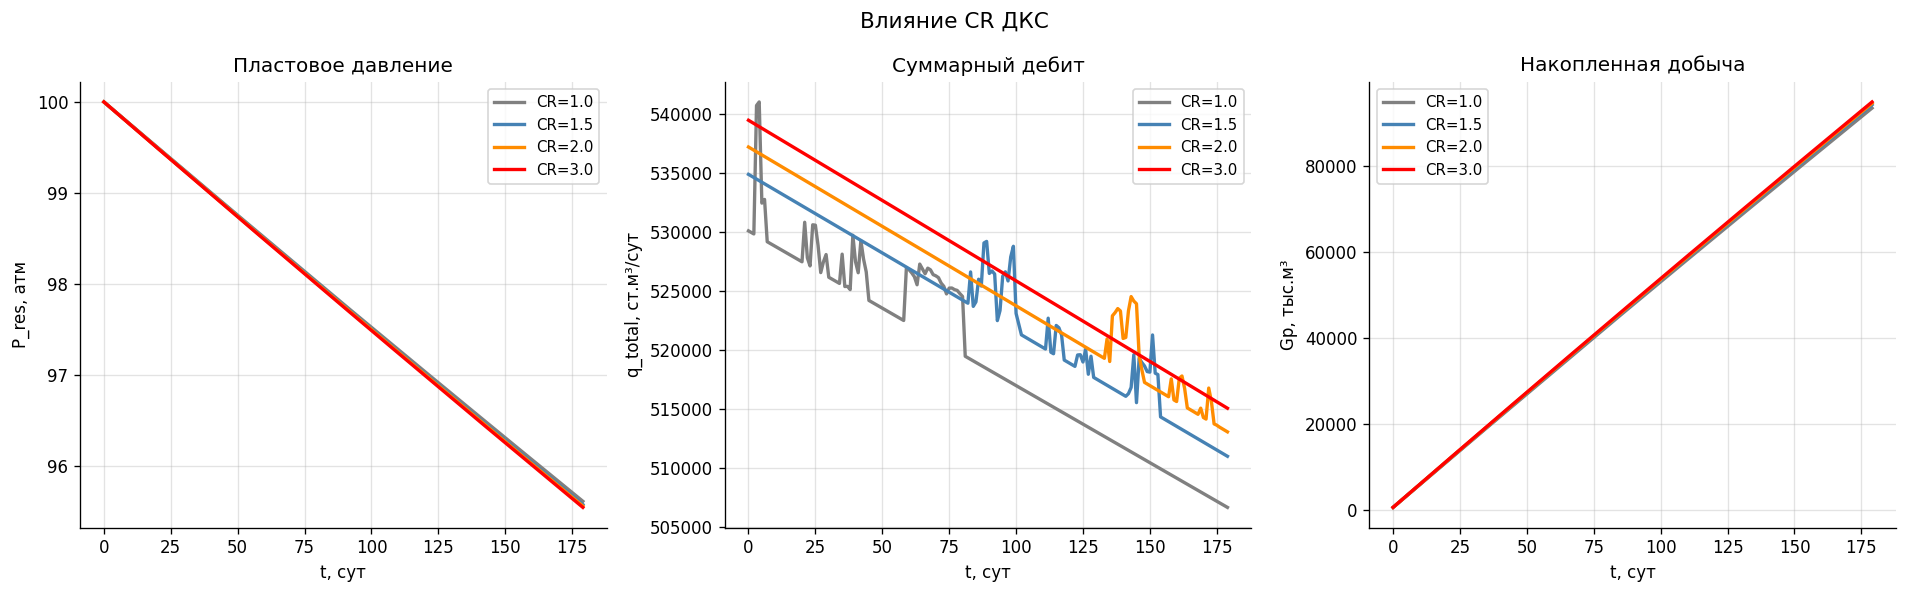

   CR     P_res конец    Gp, тыс.м³
  1.0           95.62       93485.8
  1.5           95.58       94245.3
  2.0           95.56       94593.5
  3.0           95.55       94911.5


In [34]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Влияние CR ДКС', fontsize=13)

for CR, color in zip(CR_values, cr_colors):
    d   = results_cr[CR]
    lbl = f'CR={CR}'
    axes[0].plot(d['t'], d['P_res'],   color=color, lw=2, label=lbl)
    axes[1].plot(d['t'], d['q_total'], color=color, lw=2, label=lbl)
    axes[2].plot(d['t'], d['Gp'],      color=color, lw=2, label=lbl)

axes[0].set(xlabel='t, сут', ylabel='P_res, атм',       title='Пластовое давление')
axes[1].set(xlabel='t, сут', ylabel='q_total, ст.м³/сут', title='Суммарный дебит')
axes[2].set(xlabel='t, сут', ylabel='Gp, тыс.м³',       title='Накопленная добыча')
for ax in axes: ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'{"CR":>5}  {"P_res конец":>14}  {"Gp, тыс.м³":>12}')
for CR in CR_values:
    d = results_cr[CR]
    print(f'{CR:>5}  {d["P_res"].iloc[-1]:>14.2f}  {d["Gp"].iloc[-1]:>12.1f}')

## 7. Калибровка

In [35]:
import os
from scipy.optimize import minimize

calib_path = 'adapt_gdi_11-2025.csv'
if os.path.exists(calib_path):
    df_fact = pd.read_csv(calib_path, sep=',')
    if df_fact.columns[0] == 'Unnamed: 0':
        df_fact = df_fact.iloc[:, 1:]
    print(f'Загружено {len(df_fact)} записей из {calib_path}')
    print(df_fact.head())
else:
    print('Файл не найден — генерируем синтетические данные')
    np.random.seed(42)
    n       = 30
    P_res_f = np.linspace(100, 80, n)
    P_bhp_f = P_res_f - np.random.uniform(15, 25, n)
    q_fact  = 0.35 * (P_res_f - P_bhp_f) * (1 + np.random.normal(0, 0.05, n))
    df_fact = pd.DataFrame({'P_res': P_res_f, 'P_bhp': P_bhp_f, 'q': q_fact})

df_fact = df_fact.dropna()

# Целевая колонка с дебитом
q_col = 'q_std' if 'q_std' in df_fact.columns else 'q'

_beta   = 0.00852702
_ln_rew = math.log(500 / 0.1)

def sim_q(kh, df):
    res = []
    for _, row in df.iterrows():
        if row['P_bhp'] >= row['P_res']:
            res.append(0.0); continue
        P_avg = (row['P_res'] + row['P_bhp']) / 2
        C = kh * _beta / (fluid.mu(P_avg) * _ln_rew)
        res.append(C * (row['P_res'] - row['P_bhp']))
    return np.array(res)

def rmse_func(params):
    kh = params[0]
    if kh <= 0: return 1e10
    return np.sqrt(np.mean((sim_q(kh, df_fact) - df_fact[q_col].values)**2))

opt    = minimize(rmse_func, x0=[1250.0], method='Nelder-Mead')
kh_opt = opt.x[0]

q_sim  = sim_q(kh_opt, df_fact)
q_f    = df_fact[q_col].values
rmse_v = np.sqrt(np.mean((q_sim - q_f)**2))
r2     = 1 - np.sum((q_f - q_sim)**2) / np.sum((q_f - q_f.mean())**2)

print(f'\nkh_opt = {kh_opt:.1f} мД·м  |  RMSE = {rmse_v:.2f}  |  R² = {r2:.4f}')

Загружено 50 записей из adapt_gdi_11-2025.csv
      дата well_name          q_std       P_res      P_bhp      P_thp
0   2555.0    well_3  488763.047763   98.963100  71.056718  19.133649
1      0.0    well_3  495657.359242  100.000000  72.015055  19.383816
2  10585.0    well_3  467201.982418   95.707464  68.054695  18.350489
3   2555.0    well_3  488763.047763   98.963100  71.056718  19.133649
4   3285.0    well_2  393690.676671   98.666928  82.606279  19.062255

kh_opt = 343809.7 мД·м  |  RMSE = 75944.59  |  R² = 0.6469


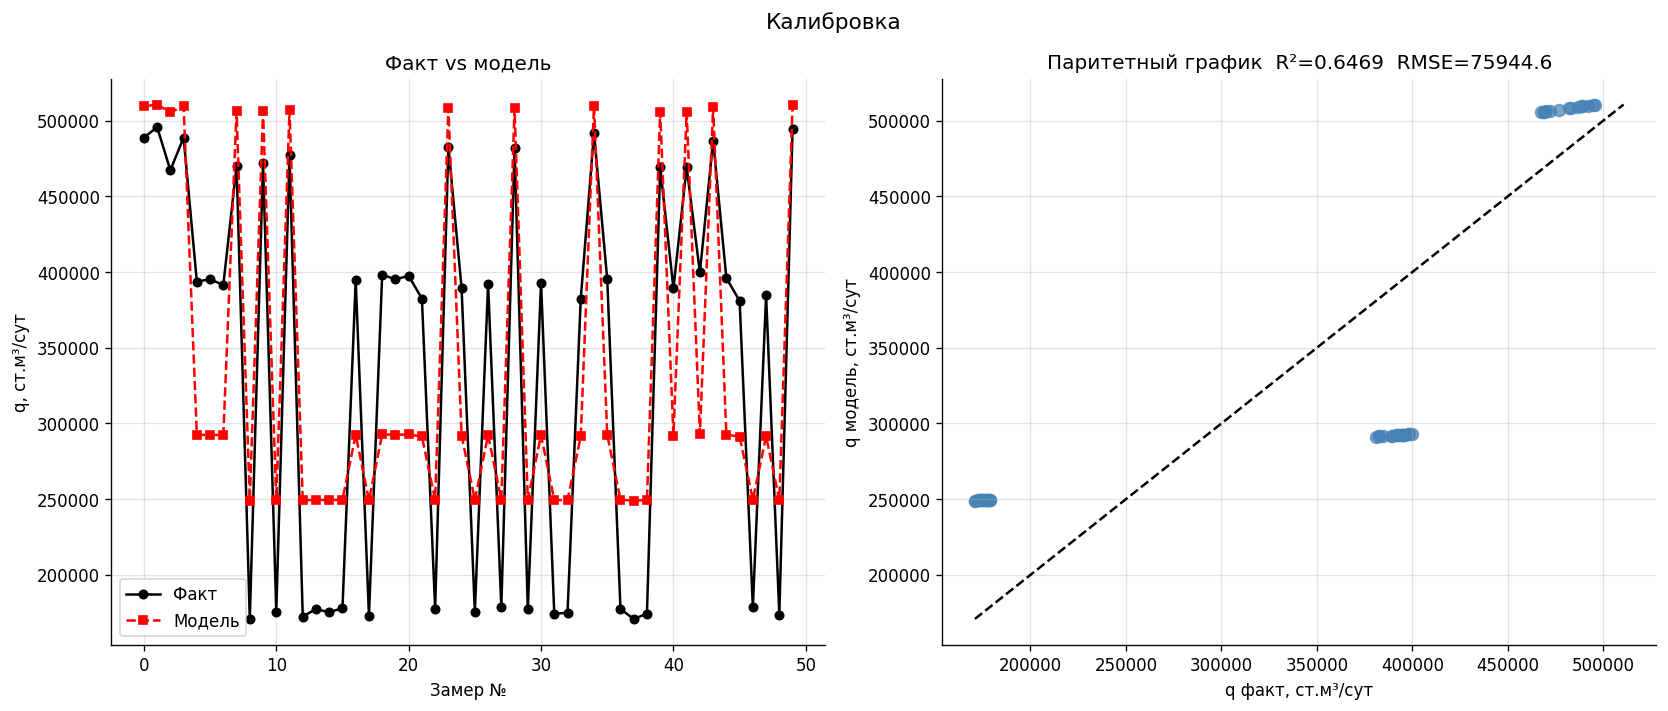

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Калибровка', fontsize=13)

axes[0].plot(q_f,   'o-', color='black', ms=5, lw=1.5, label='Факт')
axes[0].plot(q_sim, 's--', color='red',  ms=5, lw=1.5, label='Модель')
axes[0].set(xlabel='Замер №', ylabel='q, ст.м³/сут', title='Факт vs модель')
axes[0].legend()

q_min, q_max = min(q_f.min(), q_sim.min()), max(q_f.max(), q_sim.max())
axes[1].scatter(q_f, q_sim, color='steelblue', alpha=0.7, s=50)
axes[1].plot([q_min, q_max], [q_min, q_max], 'k--', lw=1.5)
axes[1].set(xlabel='q факт, ст.м³/сут', ylabel='q модель, ст.м³/сут',
            title=f'Паритетный график  R²={r2:.4f}  RMSE={rmse_v:.1f}')

plt.tight_layout()
plt.show()